In [2]:
library(HistData)

data("GaltonFamilies")

head(GaltonFamilies)
str(GaltonFamilies)
summary(GaltonFamilies)

ERROR: Error in library(HistData): there is no package called 'HistData'


The GaltonFamilies dataset contains information about the heights of children and their parents from a number of families. Each row in the dataset represents one child, and there are 934 observations with 8 variables in total. The dataset includes variables such as the height of the father, the height of the mother, the calculated midparent height, the child’s gender, and the child’s height.

From the summary statistics, the average child height is about 66.7 inches, with heights ranging from 56 inches to 79 inches. The dataset also contains slightly more male children than female children. After checking for missing values, we found that there are no missing observations, meaning the dataset is complete and can be used directly for further analysis.

In [ ]:
colSums(is.na(GaltonFamilies))

family          father          mother midparentHeight        children 
              0               0               0               0               0 
       childNum          gender     childHeight 
              0               0               0

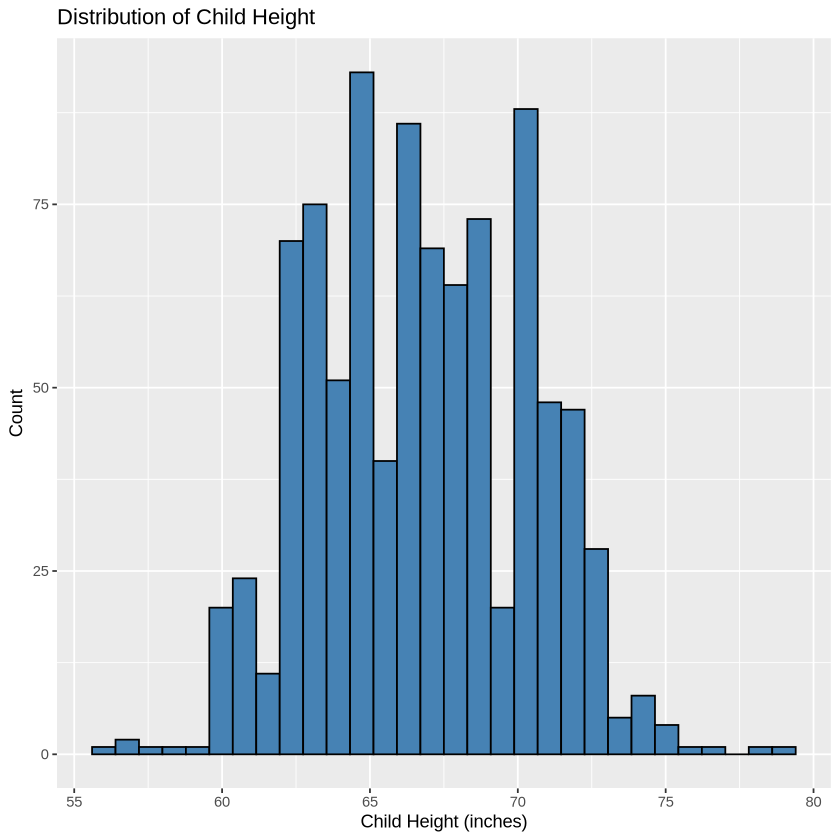

In [ ]:
library(ggplot2)

ggplot(GaltonFamilies, aes(x = childHeight)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "black") +
  labs(
    title = "Distribution of Child Height",
    x = "Child Height (inches)",
    y = "Count"
  )

The histogram shows that child heights are roughly normally distributed. Most children in the dataset have heights between about 60 and 72 inches, with the center of the distribution around 66–67 inches. There are fewer observations at the very short and very tall ends of the distribution. This pattern suggests that child height follows a fairly typical bell-shaped distribution, which is common for biological traits like height.

`geom_smooth()` using formula = 'y ~ x'


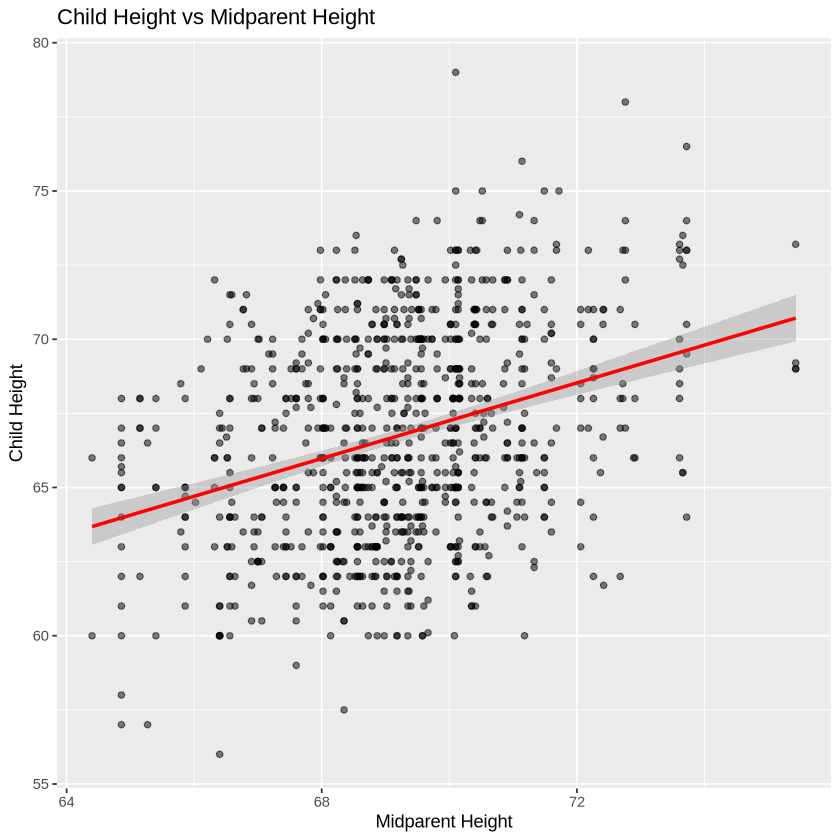

In [ ]:
ggplot(GaltonFamilies, aes(x = midparentHeight, y = childHeight)) +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", color = "red") +
  labs(
    title = "Child Height vs Midparent Height",
    x = "Midparent Height",
    y = "Child Height"
  )

This scatterplot explores the relationship between a child’s height and the average height of their parents (midparent height). There is a clear positive trend, meaning that children with taller parents tend to be taller themselves. Although there is still variability in the data, the upward trend suggests that parental height is an important factor influencing a child's height. This relationship indicates that midparent height may be a useful predictor when building a model to estimate child height.

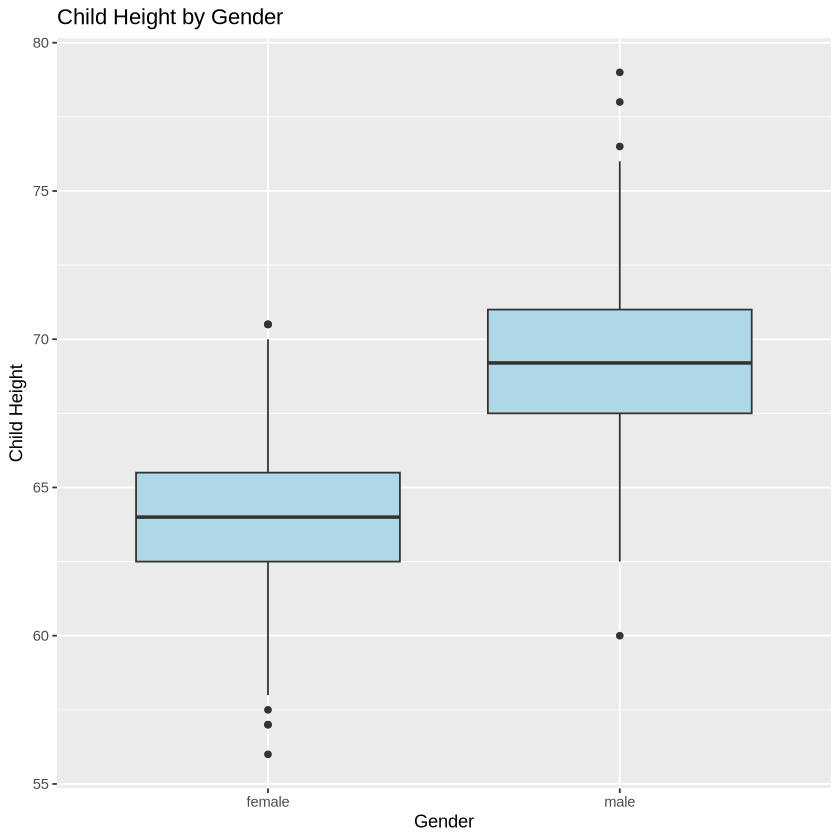

In [ ]:
ggplot(GaltonFamilies, aes(x = gender, y = childHeight)) +
  geom_boxplot(fill = "lightblue") +
  labs(
    title = "Child Height by Gender",
    x = "Gender",
    y = "Child Height"
  )

The boxplot compares the distribution of child heights between males and females. We can see that male children tend to have a slightly higher median height than female children, although the distributions overlap considerably. Both groups also show a similar spread in heights. This suggests that while gender may play a role in determining height, it is likely only one of several factors influencing a child's height.

`geom_smooth()` using formula = 'y ~ x'


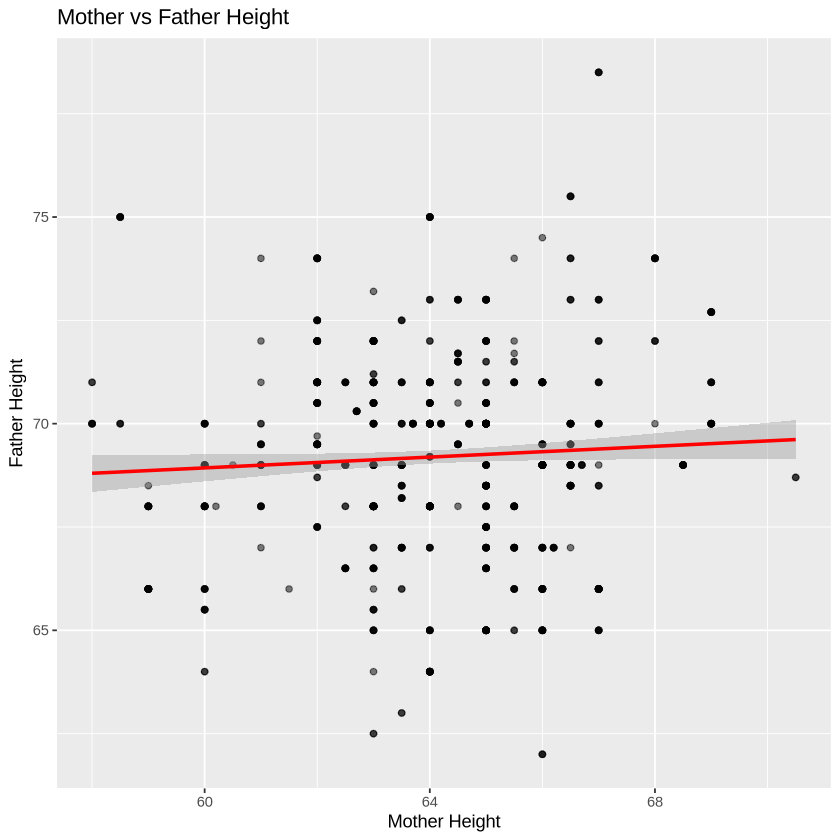

In [ ]:
ggplot(GaltonFamilies, aes(x = mother, y = father)) +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", color = "red") +
  labs(
    title = "Mother vs Father Height",
    x = "Mother Height",
    y = "Father Height"
  )

This scatterplot shows the relationship between the heights of mothers and fathers in the dataset. There appears to be a slight upward trend, suggesting that taller fathers tend to have somewhat taller partners as well. However, the points are still fairly spread out, so the relationship is not very strong. Because the two variables are somewhat related, using both mother and father height as predictors in a regression model could introduce a small amount of multicollinearity, meaning the variables may contain overlapping information about parental height.